## Теория: модель и предположения

Рассмотрим классическую форму линейной регрессии:

$$ y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_p x_{ip} + \varepsilon_i, \quad i=1,\dots,n.$$

В векторно-матрицной форме:

$$ \mathbf{y} = X\beta + \varepsilon, $$

где $X$ — матрица признаков размером $n\times (p+1)$ (первый столбец обычно единицы для свободного члена), $\beta$ — вектор коэффициентов, $\varepsilon$ — вектор шумов.

Классические предположения (Gauss-Markov):

1. Линейность модели по параметрам (модель корректно специфицирована или аппроксимирует зависимость).
2. $E[\varepsilon] = 0$.
3. Однородная дисперсия (гомоскедастичность): $Var(\varepsilon) = \sigma^2 I_n$.
4. Независимость ошибок (особенно важно при временных рядах).
5. Отсутствие точной мультиколлинеарности: матрица $X^T X$ обратима.

При выполнении предположений оценка МНК даёт BLUE (best linear unbiased estimator) — наилучшую линейную несмещённую оценку (теорема Гаусса–Маркова). Если дополнительно ошибки нормально распределены $\varepsilon\sim N(0,\sigma^2 I)$, то оценки имеют нормальное распределение и доступны точные доверительные интервалы и тесты.


## Метод наименьших квадратов

**Цель:** найти $\hat\beta$, минимизирующий сумму квадратов остатков (SSE):

$$ SSE(\beta) = \sum_{i=1}^n (y_i - x_i^T \beta)^2 = (\mathbf{y} - X\beta)^T(\mathbf{y} - X\beta). $$

Выполним дифференцирование по $\beta$ (матричный вывод):

$$ \nabla_{\beta} SSE = -2 X^T (\mathbf{y} - X\beta). $$

Приравниваем нулю:

$$ X^T X \hat\beta = X^T \mathbf{y}. $$

При условии обратимости (X^T X) получаем формулу аналитического решения (закрытая форма МНК):

$$ \boxed{\hat\beta = (X^T X)^{-1} X^T \mathbf{y}}.$$

**Геометрически:** вектор предсказаний $\hat{\mathbf{y}} = X\hat\beta$ — это ортогональная проекция $\mathbf{y}$ на подпространство столбцов матрицы (X).


## 4. Метрики качества

* SSE (sum of squared errors) — сумма квадратов остатков.
$\sum{(y_{pred} - y_i)^2}$
* MSE = SSE / n или MSE_adj = SSE / (n - p - 1).
* RMSE = $\sqrt(MSE).$
* Коэффициент детерминации $R^2 = 1 - \frac{SSE}{SST}$, где $SST = \sum (y_i - \bar y)^2$.
* Скорректированный $R^2$:

$$R^2_{adj} = 1 - (1-R^2)\frac{n-1}{n-p-1}.$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
%matplotlib inline

n = 100
x1 = np.random.uniform(0, 10, n)
x2 = np.random.normal(5, 2, n)

x1_test = np.random.uniform(0, 10, n)
x2_test = np.random.normal(5, 2, n)

# Истинные коэффициенты
beta0 = 1.5
beta1 = 2.0
beta2 = -0.7

# Шум
sigma = 1.2
eps = np.random.normal(0, sigma, n)

# Зависимая переменная
y = beta0 + beta1 * x1 + beta2 * x2 + eps

# Соберём DataFrame
df = pd.DataFrame({'y': y, 'x1': x1, 'x2': x2})
df.head()

,y,x1,x2
0,5.346721,3.745401,5.174094
1,17.086506,9.507143,4.401985
2,12.898676,7.319939,5.183522
3,11.763089,5.986585,1.024862
4,2.051129,1.560186,4.560656


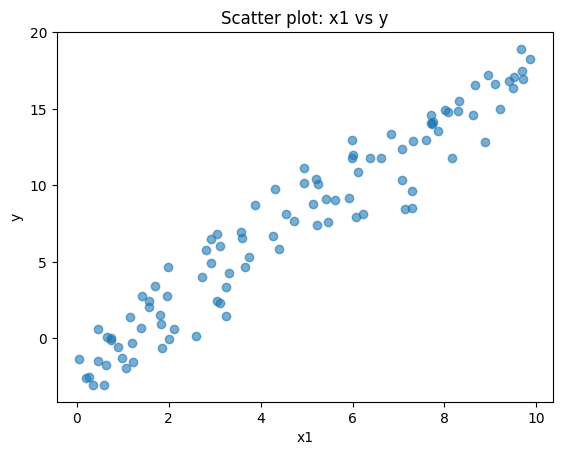

In [2]:
plt.scatter(df['x1'], df['y'], alpha=0.6)
plt.xlabel('x1')
plt.ylabel('y')
plt.title('Scatter plot: x1 vs y')
plt.show()

In [3]:
# Построим матрицу X (с константой)
X = np.column_stack([np.ones(n), df['x1'].values, df['x2'].values])
Y = df['y'].values.reshape(-1, 1)

# Аналитическая оценка
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
Xty = X.T @ Y
beta_hat = XtX_inv @ Xty
beta_hat = beta_hat.flatten()
beta_hat

array([ 1.34462106,  1.94800132, -0.60975657])

In [9]:
SSE, MSE_adj, RMSE

(144.28660744588245, 1.4874907984111594, 1.2011936040700617)

In [4]:
y_hat = X @ beta_hat.reshape(-1,1)
residuals = Y - y_hat
SSE = float((residuals**2).sum())
MSE_adj = SSE / (n - X.shape[1])
RMSE = np.sqrt(SSE / n)

# Оценки дисперсий коэффициентов
sigma2_hat = MSE_adj
cov_beta = sigma2_hat * XtX_inv
se_beta = np.sqrt(np.diag(cov_beta))

results_analytic = pd.DataFrame({
    'coef': beta_hat,
    'se': se_beta,
    't_stat': beta_hat / se_beta,
})
results_analytic.index = ['Intercept','x1','x2']
results_analytic

,coef,se,t_stat
Intercept,1.344621,0.434000,3.098206
x1,1.948001,0.041674,46.743518
x2,-0.609757,0.067900,-8.980165


In [5]:
alpha = 0.05
dof = n - X.shape[1]

t_crit = stats.t.ppf(1 - alpha/2, df=dof)
ci_lower = beta_hat - t_crit * se_beta
ci_upper = beta_hat + t_crit * se_beta

ci_df = pd.DataFrame({'lower_95': ci_lower, 'upper_95': ci_upper}, index=['Intercept','x1','x2'])
ci_df



,lower_95,upper_95
Intercept,0.483251,2.205991
x1,1.865289,2.030713
x2,-0.744520,-0.474993


In [6]:
# регрессия через statsmodels
import statsmodels.api as sm

X_sm = sm.add_constant(df[['x1','x2']])
model = sm.OLS(df['y'], X_sm)
res = model.fit()
print(res.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     1223.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.57e-69
Time:                        12:45:06   Log-Likelihood:                -160.23
No. Observations:                 100   AIC:                             326.5
Df Residuals:                      97   BIC:                             334.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3446      0.434      3.098      0.0

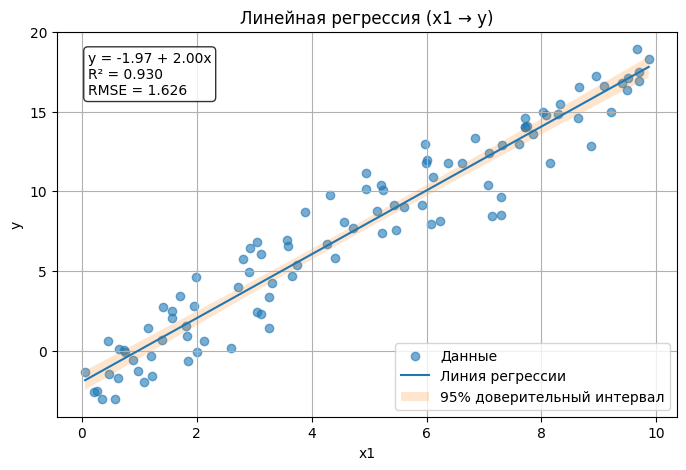

=== ПАРАМЕТРЫ МОДЕЛИ ===
const   -1.966474
x1       2.004071
dtype: float64

=== СТАНДАРТНЫЕ ОШИБКИ ===
const    0.308217
x1       0.055475
dtype: float64

=== p-values ===
const    5.873405e-09
x1       1.923537e-58
dtype: float64

R^2: 0.9301521995970791
Adj R^2: 0.9294394669399064
RMSE: 1.625554851701198


In [7]:

# Берём одну переменную для визуализации
X_plot = df[['x1']]
y_plot = df['y']

# Добавляем константу
X_plot_const = sm.add_constant(X_plot)

# Обучаем модель
model_plot = sm.OLS(y_plot, X_plot_const)
res_plot = model_plot.fit()

# Предсказания
x_range = np.linspace(X_plot.min(), X_plot.max(), 100)
X_range_const = sm.add_constant(x_range)
y_pred = res_plot.predict(X_range_const)

# Доверительный интервал
predictions = res_plot.get_prediction(X_range_const)
pred_summary = predictions.summary_frame(alpha=0.05)

# Метрики
r2 = res_plot.rsquared
rmse = np.sqrt(np.mean(res_plot.resid**2))
intercept, slope = res_plot.params

plt.figure(figsize=(8,5))

# исходные точки
plt.scatter(X_plot, y_plot, alpha=0.6, label='Данные')

# линия регрессии
plt.plot(x_range, y_pred, label='Линия регрессии')

# доверительный интервал
plt.fill_between(
    x_range.T[0],
    pred_summary['mean_ci_lower'],
    pred_summary['mean_ci_upper'],
    alpha=0.2,
    label='95% доверительный интервал'
)

plt.xlabel('x1')
plt.ylabel('y')
plt.title('Линейная регрессия (x1 → y)')


eq_text = f'y = {intercept:.2f} + {slope:.2f}x\nR² = {r2:.3f}\nRMSE = {rmse:.3f}'
plt.text(
    0.05, 0.95,
    eq_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.legend()
plt.grid(True)
plt.show()


print("=== ПАРАМЕТРЫ МОДЕЛИ ===")
print(res_plot.params)
print("\n=== СТАНДАРТНЫЕ ОШИБКИ ===")
print(res_plot.bse)
print("\n=== p-values ===")
print(res_plot.pvalues)
print("\nR^2:", r2)
print("Adj R^2:", res_plot.rsquared_adj)
print("RMSE:", rmse)

Аналитические оценки:
                coef        se     t_stat
Intercept  1.344621  0.434000   3.098206
x1         1.948001  0.041674  46.743518
x2        -0.609757  0.067900  -8.980165

Statsmodels:
          const        x1        x2
coef  1.344621  1.948001 -0.609757
se    0.434000  0.041674  0.067900


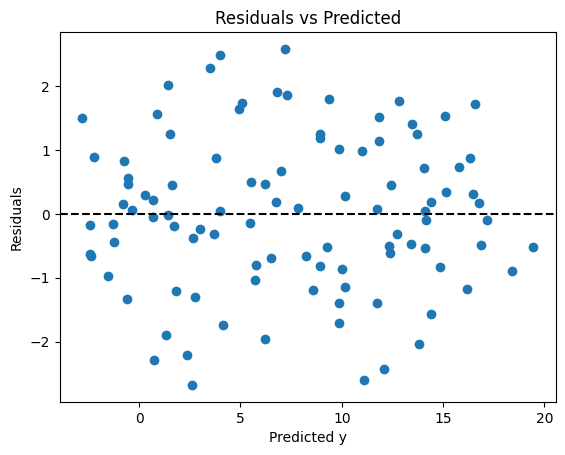

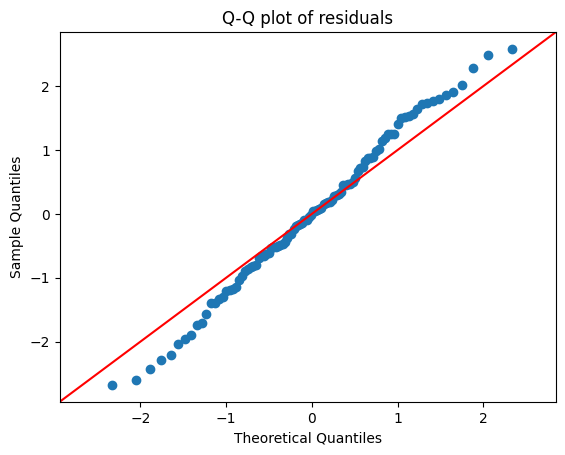

In [8]:
# Ячейка 8: сравнение
print('Аналитические оценки:\n', results_analytic)
print('\nStatsmodels:\n', pd.DataFrame({'coef': res.params, 'se': res.bse}).T)

# Ячейка 9: residuals plot
plt.scatter(y_hat, residuals)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Predicted y')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

# Ячейка 10: Q-Q plot
sm.qqplot(residuals.flatten(), line='45')
plt.title('Q-Q plot of residuals')
plt.show()
